<a href="https://colab.research.google.com/github/piaseckazaneta/Python/blob/main/30DayMapChallenge_Warszawa_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
import geopandas as gpd

# Ścieżka do Twojego folderu na Google Drive
DATA_DIR = "/content/drive/MyDrive/30daymapchallenge2026_Warsaw_pipeline/"

grid = gpd.read_parquet(DATA_DIR + "warszawa_retail_pipeline_final.parquet")
top5 = gpd.read_file(DATA_DIR + "top5_recommended_sites.geojson")
pois = gpd.read_parquet(DATA_DIR + "warszawa_pois.parquet")

print(f"Załadowano siatkę: {len(grid)} heksagonów.")

Załadowano siatkę: 5331 heksagonów.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Dict, Optional, Tuple

# Paleta Dark HUD / Cyberpunk
HUD_STYLE = {
    "bg_outer": "#06080E",       # Głęboka czerń zewnętrzna
    "bg_inner": "#0B101D",       # Ciemnogranatowy obszar mapy
    "border_subtle": "#1E293B",  # Dyskretna linia podziału
    "text_hero": "#F8FAFC",      # Czysta biel nagłówka
    "text_muted": "#CBD5E1",     # [POPRAWKA] Jaśniejszy szary dla opisów i wartości chipów
    "text_dim": "#94A3B8",       # [POPRAWKA] Znacznie jaśniejszy szary dla etykiet i stopki (było #475569)
    "accent_orange": "#F97316",  # Neonowy pomarańcz
    "accent_cyan": "#38BDF8",    # Neonowy błękit
}

def create_challenge_board(
    day_num: int,
    theme: str,
    title: str,
    subtitle: str,
    metadata_chips: Optional[Dict[str, str]] = None,
    figsize: Tuple[float, float] = (10.8, 13.5),  # 4:5 format LinkedIn (np. 1080x1350)
    dpi: int = 300,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Tworzy stałą ramkę studyjną pod posty na LinkedIn.
    Zwraca: fig oraz ax_map (oś dedykowaną na mapę).
    """
    fig = plt.figure(figsize=figsize, dpi=dpi, facecolor=HUD_STYLE["bg_outer"])

    # 1. Główny kontener planszy
    ax_board = fig.add_axes([0, 0, 1, 1])
    ax_board.set_facecolor(HUD_STYLE["bg_outer"])
    ax_board.set_xlim(0, 1)
    ax_board.set_ylim(0, 1)
    ax_board.axis("off")

    # Zewnętrzny elegancki border
    outer_card = patches.FancyBboxPatch(
        (0.025, 0.02),
        0.95,
        0.96,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.2,
        edgecolor=HUD_STYLE["border_subtle"],
        facecolor=HUD_STYLE["bg_outer"],
        zorder=1,
    )
    ax_board.add_patch(outer_card)

    # 2. HEADER
    header_tag = f"#30DAYMAPCHALLENGE 2026  //  DAY {day_num:02d}: {theme.upper()}"
    ax_board.text(
        0.055, 0.940, header_tag,
        color=HUD_STYLE["accent_orange"], fontsize=9.5, fontfamily="monospace", fontweight="bold",
        va="center", zorder=3
    )

    ax_board.text(
        0.945, 0.940, "WARSZAWA LOCATION INTELLIGENCE",
        color=HUD_STYLE["text_dim"], fontsize=8, fontfamily="monospace", ha="right", va="center", zorder=3
    )

    ax_board.text(
        0.055, 0.900, title,
        color=HUD_STYLE["text_hero"], fontsize=17.5, fontweight="bold", fontfamily="sans-serif",
        va="center", zorder=3
    )

    ax_board.text(
        0.055, 0.865, subtitle,
        color=HUD_STYLE["text_muted"], fontsize=10, fontfamily="sans-serif",
        va="center", zorder=3
    )

    # Linia podziału nagłówka
    ax_board.plot([0.055, 0.945], [0.840, 0.840], color=HUD_STYLE["border_subtle"], lw=0.8, zorder=3)

    # 3. GŁÓWNA OŚ MAPY (Centralny obszar roboczy)
    ax_map = fig.add_axes([0.055, 0.135, 0.89, 0.685])
    ax_map.set_facecolor(HUD_STYLE["bg_inner"])
    ax_map.set_axis_off()

    # Tło z zaokrąglonymi narożnikami
    map_box = patches.FancyBboxPatch(
        (0.0, 0.0), 1.0, 1.0,
        transform=ax_map.transAxes,
        boxstyle="round,pad=0.0,rounding_size=0.015",
        linewidth=1.0, edgecolor=HUD_STYLE["border_subtle"], facecolor=HUD_STYLE["bg_inner"],
        clip_on=False, zorder=0
    )
    ax_map.add_patch(map_box)

    # Celowniki techniczne w rogach (crosshairs HUD)
    ch_s = 0.025
    c_col = HUD_STYLE["accent_cyan"]
    # Lewy górny
    ax_map.plot([0.02, 0.02 + ch_s], [0.98, 0.98], color=c_col, lw=1.2, transform=ax_map.transAxes, zorder=10)
    ax_map.plot([0.02, 0.02], [0.98 - ch_s, 0.98], color=c_col, lw=1.2, transform=ax_map.transAxes, zorder=10)
    # Prawy dolny
    ax_map.plot([0.98 - ch_s, 0.98], [0.02, 0.02], color=c_col, lw=1.2, transform=ax_map.transAxes, zorder=10)
    ax_map.plot([0.98, 0.98], [0.02, 0.02 + ch_s], color=c_col, lw=1.2, transform=ax_map.transAxes, zorder=10)

    # 4. CHIPY METADANYCH (Karty informacyjne na dole)
    if metadata_chips is None:
        metadata_chips = {
            "DATA SOURCE": "OpenStreetMap",
            "PROJECTION": "EPSG:2180",
            "ENGINE": "GeoPandas",
            "STATUS": "Cleaned POI"
        }

    n_chips = len(metadata_chips)
    chip_w = 0.89 / n_chips
    start_x = 0.055

    for i, (k, v) in enumerate(metadata_chips.items()):
        cx = start_x + i * chip_w
        cy = 0.075
        cw = chip_w - 0.012
        ch = 0.042

        chip_bg = patches.FancyBboxPatch(
            (cx, cy), cw, ch,
            boxstyle="round,pad=0.005,rounding_size=0.008",
            linewidth=0.7, edgecolor=HUD_STYLE["border_subtle"], facecolor="#101726", zorder=3
        )
        ax_board.add_patch(chip_bg)

        ax_board.text(cx + 0.01, cy + ch * 0.68, k, color=HUD_STYLE["text_dim"], fontsize=6.5, fontfamily="monospace", fontweight="bold", va="center", zorder=4)
        ax_board.text(cx + 0.01, cy + ch * 0.28, v, color=HUD_STYLE["text_muted"], fontsize=8, fontfamily="monospace", fontweight="bold", va="center", zorder=4)

    # 5. FOOTER
    ax_board.text(
        0.055, 0.038,
        "Source: OpenStreetMap Contributors | Site Selection Engine: Warsaw Retail Expansion",
        color=HUD_STYLE["text_dim"], fontsize=7.5, fontfamily="monospace", va="center", zorder=3
    )
    ax_board.text(
        0.945, 0.038,
        "Warsaw Convenience ML",
        color=HUD_STYLE["accent_orange"], fontsize=8, fontfamily="monospace", fontweight="bold", ha="right", va="center", zorder=3
    )

    return fig, ax_map

/tmp/ipykernel_2584/4020404237.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts_x = active_cells.geometry.centroid.x
/tmp/ipykernel_2584/4020404237.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts_y = active_cells.geometry.centroid.y
/tmp/ipykernel_2584/4020404237.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  st_x = stores.geometry.centroid.x
/tmp/ipykernel_2584/4020404237.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before thi

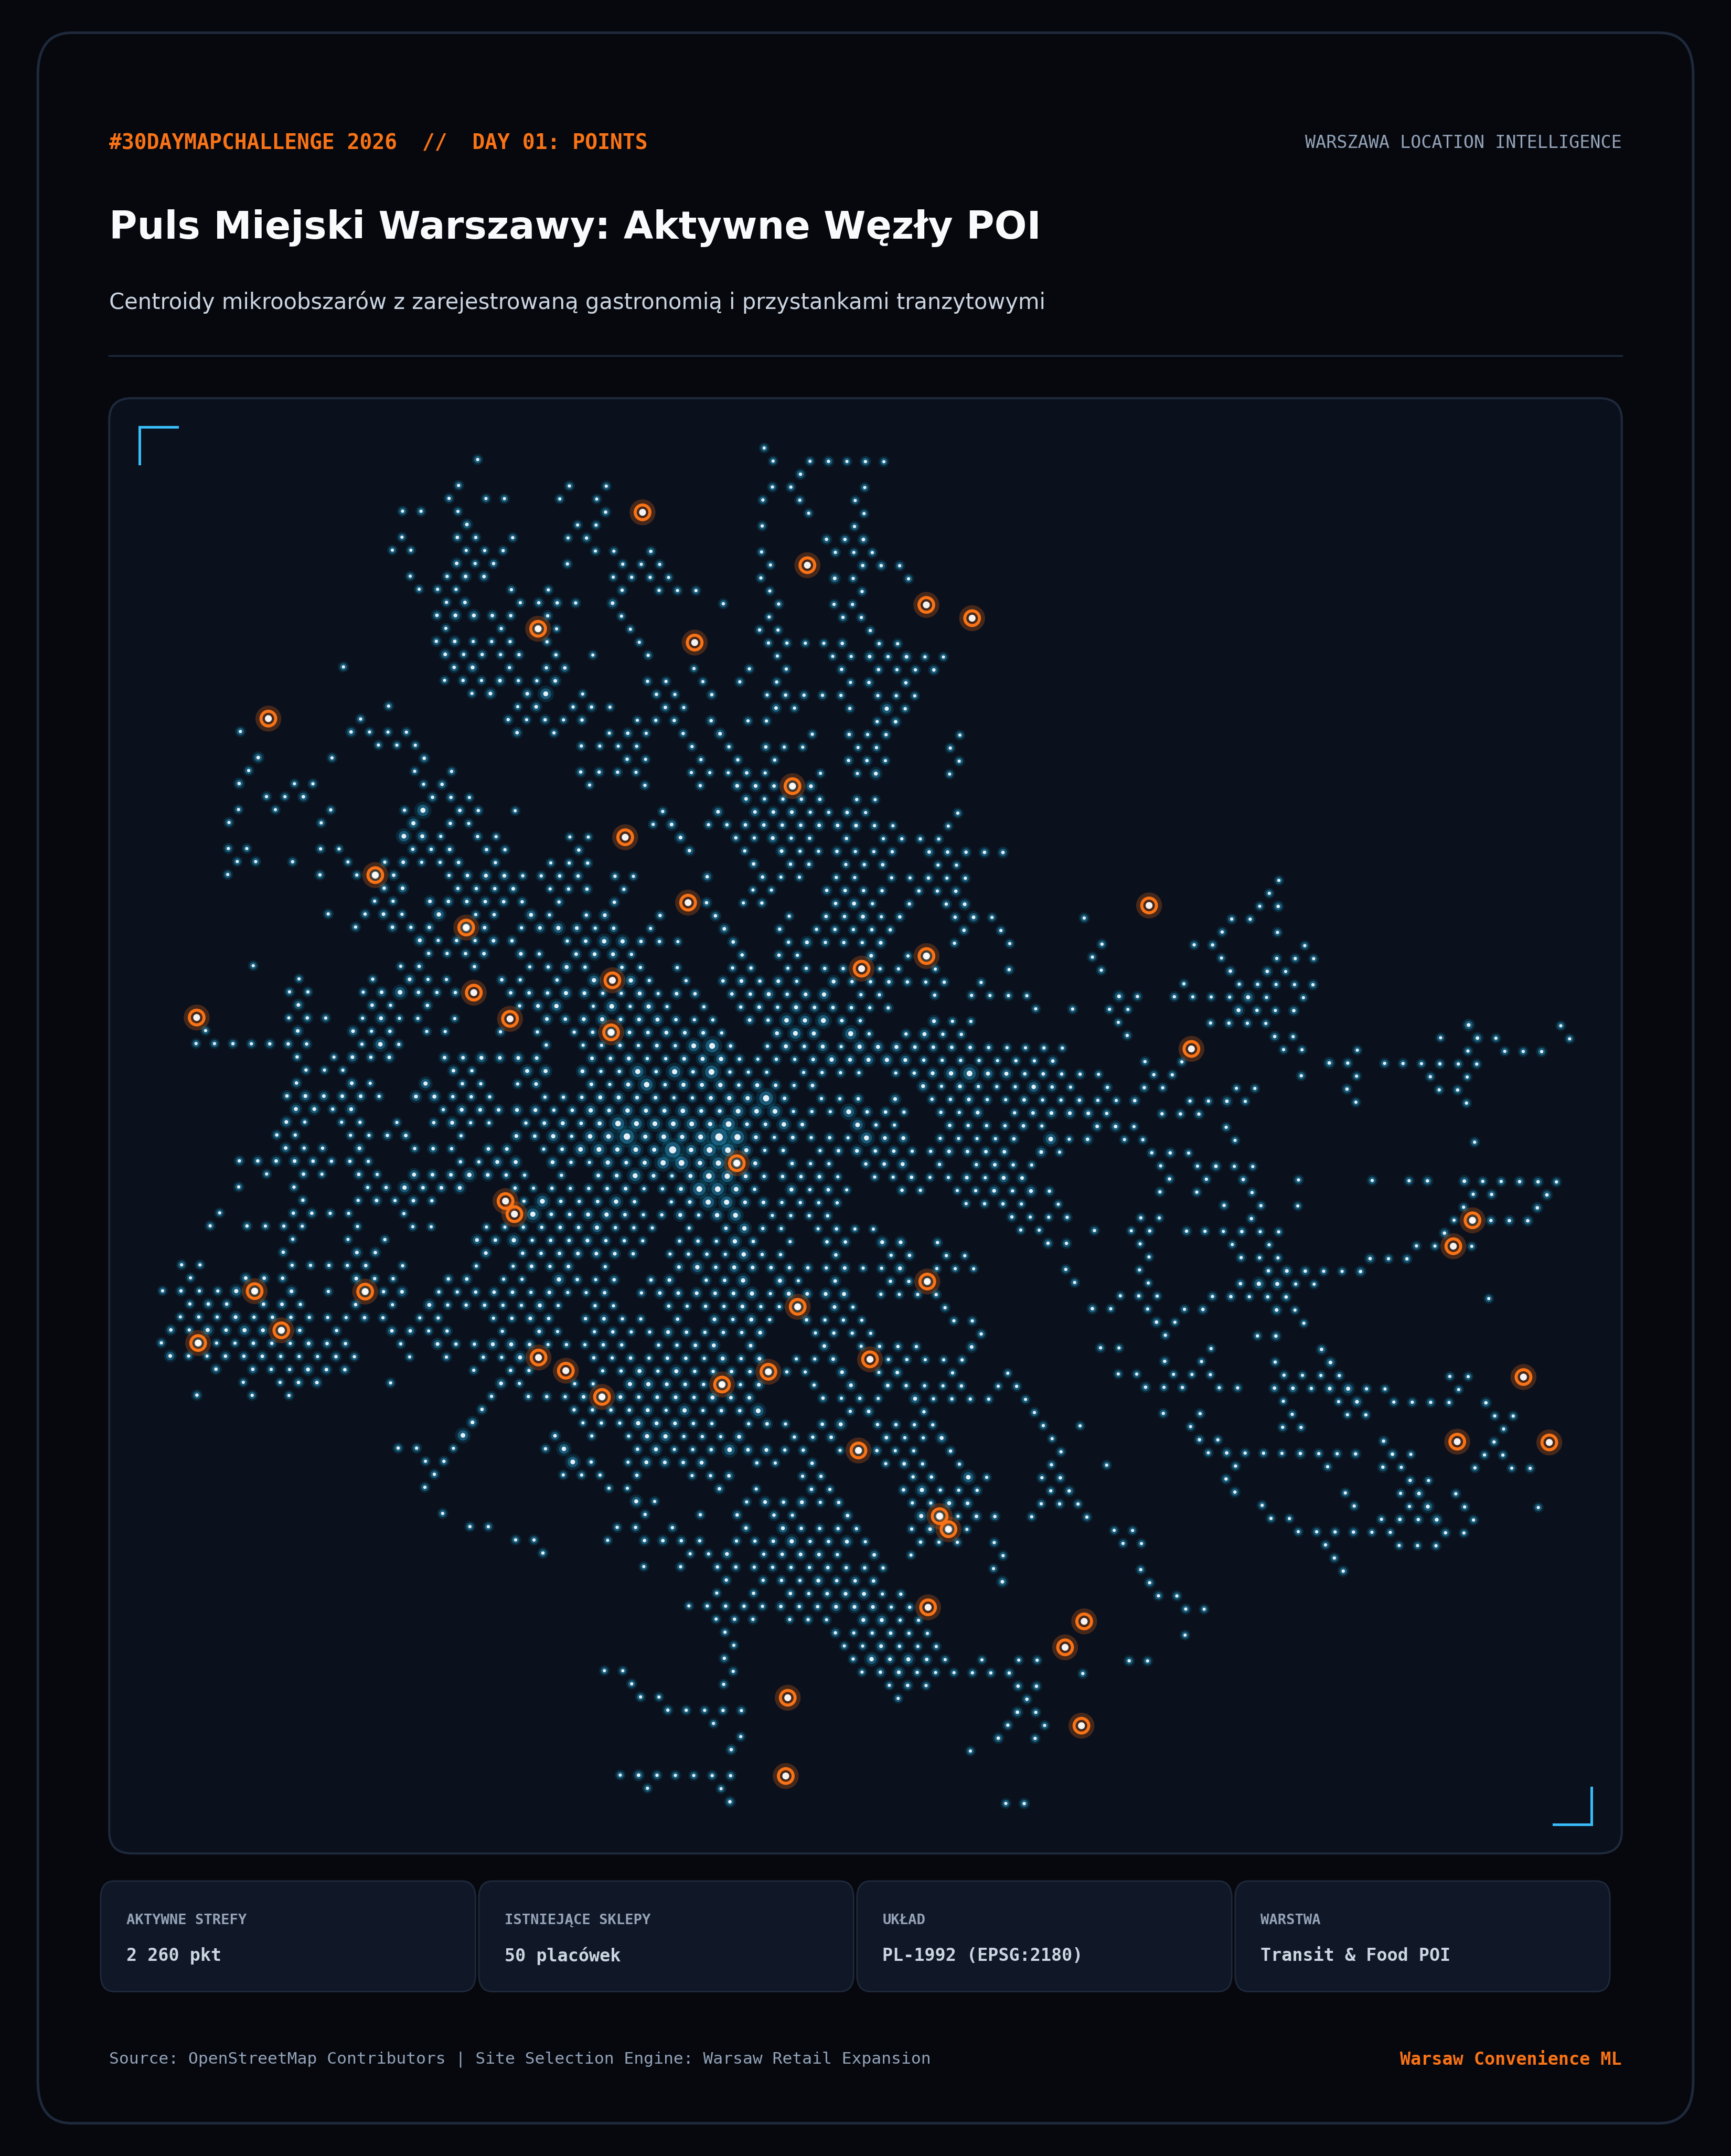

✅ Wygenerowano zaktualizowaną planszę: day01_points_warszawa_v2.png


In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Ścieżka do Twoich plików
PATH = "/content/drive/MyDrive/30daymapchallenge2026_Warsaw_pipeline/"

# Wczytujemy dane
grid = gpd.read_parquet(PATH + "warszawa_retail_pipeline_final.parquet")

active_cells = grid[(grid['transit_stops'] > 0) | (grid['food_places'] > 0)].copy()
stores = grid[grid['has_own_store'] == True].copy()

# Centroidy w układzie metrycznym PL-1992
pts_x = active_cells.geometry.centroid.x
pts_y = active_cells.geometry.centroid.y

# --- [NOWOŚĆ] Skalowanie wielkości punktów na bazie sumy POI ---
weights = active_cells['transit_stops'] + active_cells['food_places']
# Punkty o małej aktywności mają bazowy rozmiar, a w ścisłym centrum rosną proporcjonalnie
sizes = 8 + (weights / weights.max()) * 40

# 2. Inicjalizacja ramki
fig, ax_map = create_challenge_board(
    day_num=1,
    theme="Points",
    title="Puls Miejski Warszawy: Aktywne Węzły POI",
    subtitle="Centroidy mikroobszarów z zarejestrowaną gastronomią i przystankami tranzytowymi",
    metadata_chips={
        "AKTYWNE STREFY": f"{len(active_cells):,} pkt".replace(",", " "),
        "ISTNIEJĄCE SKLEPY": f"{len(stores)} placówek",
        "UKŁAD": "PL-1992 (EPSG:2180)",
        "WARSTWA": "Transit & Food POI"
    }
)

# 3. Rysowanie punktów z efektem Neon Glow (ze skalowaniem)
# WARSTWA 1: Zewnętrzna mgławica / aura (delikatna poświata)
ax_map.scatter(pts_x, pts_y, s=sizes * 2.8, color="#06B6D4", alpha=0.15, edgecolors="none", zorder=3)

# WARSTWA 2: Wewnętrzna łuna (nieco jaśniejsza i bardziej skupiona)
ax_map.scatter(pts_x, pts_y, s=sizes * 1.2, color="#38BDF8", alpha=0.35, edgecolors="none", zorder=4)

# WARSTWA 3: Ostry rdzeń światła (biel / jasny cyjan)
ax_map.scatter(pts_x, pts_y, s=sizes * 0.25, color="#F0F9FF", alpha=0.95, edgecolors="none", zorder=5)

# 4. Istniejące placówki sieci (Mocny pomarańczowy neon)
if len(stores) > 0:
    st_x = stores.geometry.centroid.x
    st_y = stores.geometry.centroid.y
    # Glow sklepu
    ax_map.scatter(st_x, st_y, s=140, color="#F97316", alpha=0.25, edgecolors="none", zorder=6)
    # Pierścień techniczny
    ax_map.scatter(st_x, st_y, s=45, facecolors="none", edgecolors="#F97316", linewidth=1.4, zorder=7)
    # Rdzeń punktu
    ax_map.scatter(st_x, st_y, s=10, color="#FFFFFF", alpha=0.95, edgecolors="none", zorder=8)

# Dopasowanie granic widoku z marginesem 3%
minx, miny, maxx, maxy = active_cells.total_bounds
padx = (maxx - minx) * 0.03
pady = (maxy - miny) * 0.03
ax_map.set_xlim(minx - padx, maxx + padx)
ax_map.set_ylim(miny - pady, maxy + pady)

# 5. Zapis
output_path = "day01_points_warszawa_v2.png"
fig.savefig(output_path, dpi=300, facecolor=fig.get_facecolor(), edgecolor="none")
plt.show()

print(f"✅ Wygenerowano zaktualizowaną planszę: {output_path}")